In [24]:
!pip install medmnist

In [25]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import medmnist
from medmnist import INFO
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import numpy as np

In [26]:
# Load dataset
data_flag = 'chestmnist'
info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])
DataClass = getattr(medmnist, info['python_class'])
train_dataset = DataClass(split='train', transform=transforms.ToTensor(), download=True)
test_dataset = DataClass(split='test', transform=transforms.ToTensor(), download=True)

In [27]:
train_loader = data.DataLoader(dataset=train_dataset, batch_size=100, shuffle=True)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=100, shuffle=False)

In [28]:
# Define CNN autoencoder model (encoder & decoder)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
kernel_size = 5

class autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(n_channels, 6, kernel_size)
        self.conv2 = nn.Conv2d(6, 12, kernel_size)
        self.pool = nn.MaxPool2d(2, 2)
        self.iconv1 = nn.ConvTranspose2d(12, 6, kernel_size+1, stride=2)
        self.iconv2 = nn.ConvTranspose2d(6, n_channels, kernel_size+1, stride=2)
    def encode(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        return x

    def decode(self, x):
        x = F.relu(self.iconv1(x))
        x = torch.sigmoid(self.iconv2(x))
        return x

    def forward(self, x):
        return self.decode(self.encode(x))

model = autoencoder().to(device)
print(device)

cuda


In [29]:
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
# Epoch
n_epochs = 10
train_loss = []
test_loss = []

In [30]:
# Train and evaluate the model
for epoch in range(n_epochs):
    # Train the model
    model.train()
    loss_run = 0.0
    for data in train_loader:
        images, _ = data
        images = images.to(device)
        optimizer.zero_grad()
        outputs = model.forward(images)
        loss = F.mse_loss(outputs, images)
        loss.backward()
        optimizer.step()
        loss_run += loss.item() * images.size(0)

    train_loss.append(loss_run / len(train_loader.dataset))

    # Evaluate the model
    model.eval()
    test_loss_run = 0.0
    with torch.no_grad():
        for test_data in test_loader:
            test_images, _ = test_data
            test_images = test_images.to(device)
            test_outputs = model.forward(test_images)
            loss = F.mse_loss(test_outputs, test_images)
            test_loss_run += loss.item() * test_images.size(0)

    test_loss.append(test_loss_run / len(test_loader.dataset))

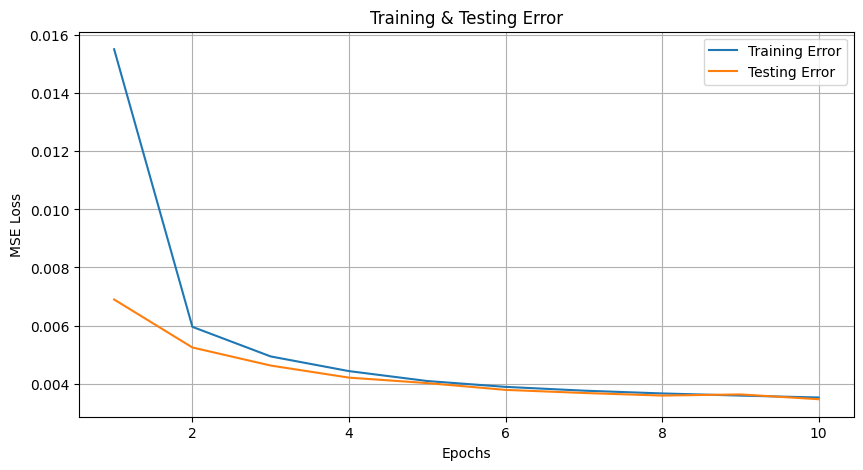

In [31]:
# Compare train and test loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs+1), train_loss, label='Training Error')
plt.plot(range(1, n_epochs+1), test_loss, label='Testing Error')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training & Testing Error')
plt.legend()
plt.grid(True)
plt.show()

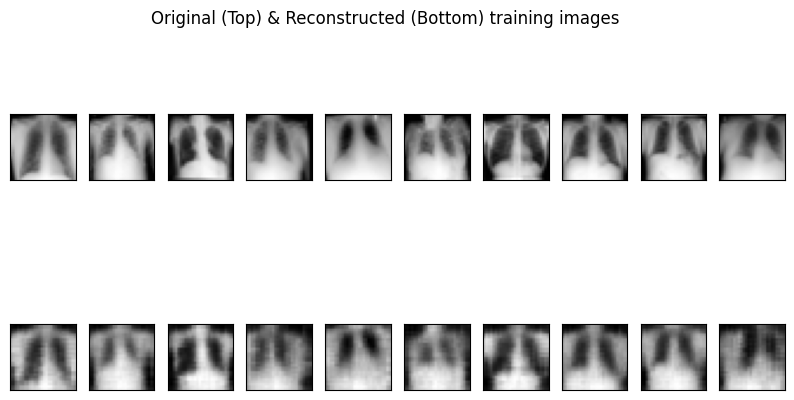

In [32]:
# Feed the model with training images
train_sample = images.cpu().detach().numpy()
train_output = outputs.cpu().detach().numpy()

plt.figure(figsize=(10, 5))
plt.suptitle("Original (Top) & Reconstructed (Bottom) training images")
for i in range(10):
    # Train Images
    plt.subplot(2, 10, i + 1)
    plt.xticks([])
    plt.yticks([])
    img = np.transpose(train_sample[i,:,:,:], (1, 2, 0))
    plt.imshow(img.squeeze(), cmap='gray')

    # Reconstructed Train Images
    plt.subplot(2, 10, i + 11)
    plt.xticks([])
    plt.yticks([])
    img = np.transpose(train_output[i,:,:,:], (1, 2, 0))
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

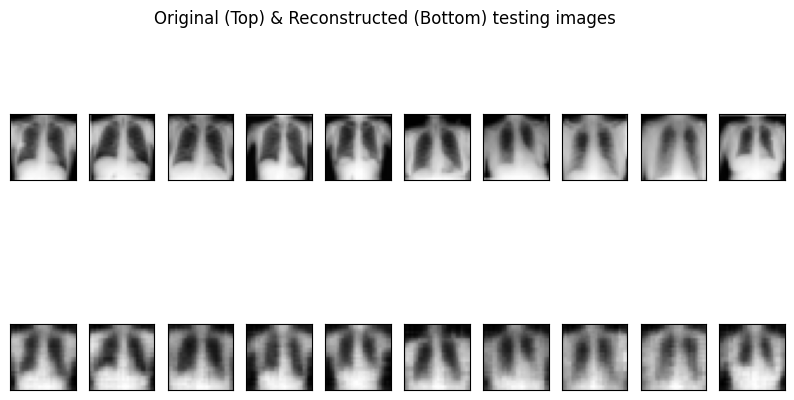

In [34]:
# Feed the model with test images
test_img, _ = next(iter(test_loader))
test_sample = model(test_img.to(device)).detach().cpu().numpy()

plt.figure(figsize=(10, 5))
plt.suptitle("Original (Top) & Reconstructed (Bottom) testing images")
for i in range(10):
    # Original Test Images
    plt.subplot(2, 10, i + 1)
    plt.xticks([])
    plt.yticks([])
    img = np.transpose(test_img[i,:,:,:], (1, 2, 0))
    plt.imshow(img.squeeze(), cmap='gray')

    # Reconstructed Test Images
    plt.subplot(2, 10, i + 11)
    plt.xticks([])
    plt.yticks([])
    img = np.transpose(test_sample[i,:,:,:], (1, 2, 0))
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()